In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(r"C:\Personal\Masters\Masters_work\Study\Y2_S1\PRT661\Project\Data-Science-practise-PRT661\development folder\Cleaned_data_final.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (120978, 13)


,Unnamed: 0,Country of birth of person,Years spent in Australia,Age group,Sex,Long-term health condition (LTHC),Number of people reporting LTHC(s),Population,Age-specific percentage of population reporting LTHC(s),Language used at home,Proficiency in spoken English,Region_class,Subregion_class
0,0,"Oceania and Antarctica, nfd",0–10 years,00–44,Persons,Arthritis,0.0,0.0,0.0,.ATSI lang,Not specified,Oceania and Antarctica,Oceania (nfd)
1,1,"Oceania and Antarctica, nfd",0–10 years,00–44,Male,Arthritis,0.0,0.0,0.0,.ATSI lang,Not specified,Oceania and Antarctica,Oceania (nfd)
2,2,"Oceania and Antarctica, nfd",0–10 years,00–44,Female,Arthritis,0.0,0.0,0.0,.ATSI lang,Not specified,Oceania and Antarctica,Oceania (nfd)
3,3,"Oceania and Antarctica, nfd",0–10 years,45–64,Persons,Arthritis,0.0,0.0,0.0,.ATSI lang,Not specified,Oceania and Antarctica,Oceania (nfd)
4,4,"Oceania and Antarctica, nfd",0–10 years,45–64,Male,Arthritis,0.0,0.0,0.0,.ATSI lang,Not specified,Oceania and Antarctica,Oceania (nfd)


In [ ]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print("Dataset shape:", df.shape)

Dataset shape: (120978, 12)


In [ ]:
print("Columns:")

for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

df.info()

Columns:
1. Country of birth of person
2. Years spent in Australia
3. Age group
4. Sex
5. Long-term health condition (LTHC)
6. Number of people reporting LTHC(s)
7. Population
8. Age-specific percentage of population reporting LTHC(s)
9. Language used at home
10. Proficiency in spoken English
11. Region_class
12. Subregion_class
<class 'pandas.DataFrame'>
RangeIndex: 120978 entries, 0 to 120977
Data columns (total 12 columns):
 #   Column                                                   Non-Null Count   Dtype  
---  ------                                                   --------------   -----  
 0   Country of birth of person                               120978 non-null  str    
 1   Years spent in Australia                                 120978 non-null  str    
 2   Age group                                                120978 non-null  str    
 3   Sex                                                      120978 non-null  str    
 4   Long-term health condition (LTHC)         

In [ ]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df) * 100).round(2)
})

missing_df[missing_df["Missing Values"] > 0].sort_values(
    "Percentage",
    ascending=False
)

,Missing Values,Percentage


In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

print(
    "Duplicate percentage:",
    round(duplicates / len(df) * 100, 2),
    "%"
)

Duplicate rows: 0
Duplicate percentage: 0.0 %


In [ ]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

for col in categorical_columns:
    print("\n" + "=" * 60)
    print(col)
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(10))


Country of birth of person
Unique values: 270
Country of birth of person
India                               3510
Myanmar                             2106
Philippines                         2106
China (excludes SARs and Taiwan)    1872
Liberia                             1872
Oceania and Antarctica, nfd         1638
Eastern Europe, nfd                 1638
Papua New Guinea                    1404
South Sudan                         1404
Northern Europe, nfd                1170
Name: count, dtype: int64

Years spent in Australia
Unique values: 3
Years spent in Australia
Not specified         57798
0–10 years            31590
More than 10 years    31590
Name: count, dtype: int64

Age group
Unique values: 3
Age group
00–44          40326
45–64          40326
65 and over    40326
Name: count, dtype: int64

Sex
Unique values: 3
Sex
Persons    40326
Male       40326
Female     40326
Name: count, dtype: int64

Long-term health condition (LTHC)
Unique values: 13
Long-term health condition (L

<ipython-input-7-127650b57361>:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [ ]:
numerical_columns = df.select_dtypes(
    exclude="object"
).columns

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Number of people reporting LTHC(s),120978.0,124.932756,1400.598508,0.0,0.0,0.0,0.0,213336.0
Population,120978.0,1877.919002,12450.273469,0.0,0.0,0.0,0.0,402722.0
Age-specific percentage of population reporting LTHC(s),120978.0,1.635266,6.986686,0.0,0.0,0.0,0.0,90.0


In [ ]:
zero_population = df["Population"] == 0

print("Zero population rows:", zero_population.sum())

print(
    "Percentage:",
    round(zero_population.mean() * 100, 2),
    "%"
)

Zero population rows: 104794
Percentage: 86.62 %


In [ ]:
df.loc[zero_population].head(20)

,Country of birth of person,Years spent in Australia,Age group,Sex,Long-term health condition (LTHC),Number of people reporting LTHC(s),Population,Age-specific percentage of population reporting LTHC(s),Language used at home,Proficiency in spoken English,Region_class,Subregion_class
0,"Oceania and Antarctica, nfd",0–10 years,00–44,Persons,Arthritis,0.0,0.0,0.0,.ATSI lang,Not specified,Oceania and Antarctica,Oceania (nfd)
1,"Oceania and Antarctica, nfd",0–10 years,00–44,Male,Arthritis,0.0,0.0,0.0,.ATSI lang,Not specified,Oceania and Antarctica,Oceania (nfd)
2,"Oceania and Antarctica, nfd",0–10 years,00–44,Female,Arthritis,0.0,0.0,0.0,.ATSI lang,Not specified,Oceania and Antarctica,Oceania (nfd)
3,"Oceania and Antarctica, nfd",0–10 years,45–64,Persons,Arthritis,0.0,0.0,0.0,.ATSI lang,Not specified,Oceania and Antarctica,Oceania (nfd)
4,"Oceania and Antarctica, nfd",0–10 years,45–64,Male,Arthritis,0.0,0.0,0.0,.ATSI lang,Not specified,Oceania and Antarctica,Oceania (nfd)
5,"Oceania and Antarctica, nfd",0–10 years,45–64,Female,Arthritis,0.0,0.0,0.0,.ATSI lang,Not specified,Oceania and Antarctica,Oceania (nfd)
6,"Oceania and Antarctica, nfd",0–10 years,65 and over,Persons,Arthritis,0.0,0.0,0.0,.ATSI lang,Not specified,Oceania and Antarctica,Oceania (nfd)
7,"Oceania and Antarctica, nfd",0–10 years,65 and over,Male,Arthritis,0.0,0.0,0.0,.ATSI lang,Not specified,Oceania and Antarctica,Oceania (nfd)
8,"Oceania and Antarctica, nfd",0–10 years,65 and over,Female,Arthritis,0.0,0.0,0.0,.ATSI lang,Not specified,Oceania and Antarctica,Oceania (nfd)
9,"Oceania and Antarctica, nfd",More than 10 years,00–44,Persons,Arthritis,0.0,0.0,0.0,.ATSI lang,Not specified,Oceania and Antarctica,Oceania (nfd)


In [ ]:
df["calculated_prevalence"] = np.where(
    df["Population"] > 0,
    (
        df["Number of people reporting LTHC(s)"]
        / df["Population"]
    ) * 100,
    0
)

difference = (
    df["calculated_prevalence"]
    - df["Age-specific percentage of population reporting LTHC(s)"]
).abs()

print("Maximum difference:", difference.max())
print("Mean difference:", difference.mean())

Maximum difference: 5.000000413701855e-09
Mean difference: 6.785447936010854e-11


In [ ]:
target = "Age-specific percentage of population reporting LTHC(s)"

leakage_columns = [
    "Number of people reporting LTHC(s)",
    "Population"
]

print("Target:")
print(target)

print("\nPotential leakage variables:")

for col in leakage_columns:
    print("-", col)

Target:
Age-specific percentage of population reporting LTHC(s)

Potential leakage variables:
- Number of people reporting LTHC(s)
- Population


In [ ]:
lthc_counts = df["Long-term health condition (LTHC)"].value_counts()

print("Number of LTHC categories:", len(lthc_counts))

print("\nLTHC distribution:")
print(lthc_counts)

Number of LTHC categories: 13

LTHC distribution:
Long-term health condition (LTHC)
Arthritis                                    9306
Asthma                                       9306
Cancer                                       9306
Dementia                                     9306
Diabetes                                     9306
Heart disease                                9306
Kidney disease                               9306
Lung condition                               9306
Mental health condition                      9306
Stroke                                       9306
Heart disease or stroke                      9306
Any other long-term health condition(s)      9306
One or more long-term health condition(s)    9306
Name: count, dtype: int64


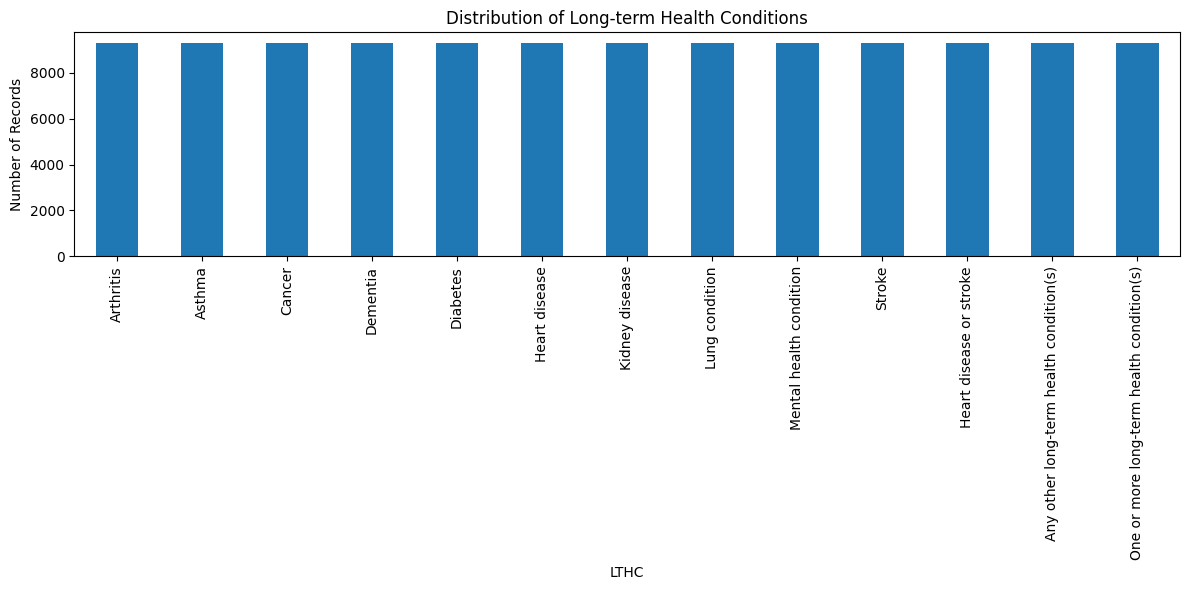

In [ ]:
plt.figure(figsize=(12, 6))

lthc_counts.plot(kind="bar")

plt.title("Distribution of Long-term Health Conditions")
plt.xlabel("LTHC")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

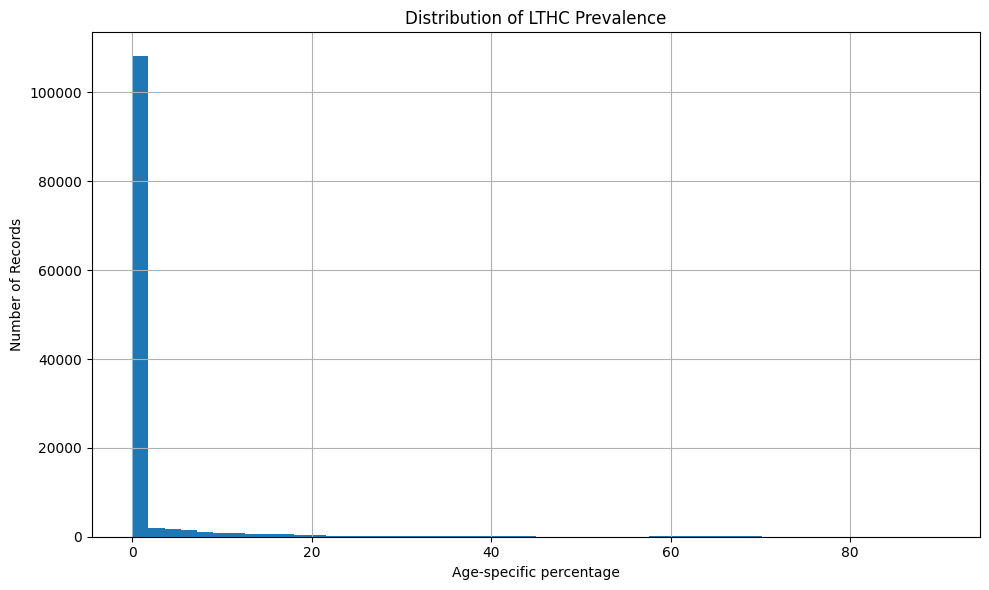

In [ ]:
plt.figure(figsize=(10, 6))

df[target].hist(bins=50)

plt.title("Distribution of LTHC Prevalence")
plt.xlabel("Age-specific percentage")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

In [ ]:
print(df["Age group"].value_counts())

Age group
00–44          40326
45–64          40326
65 and over    40326
Name: count, dtype: int64


In [ ]:
lthc_prevalence = (
    df.groupby("Long-term health condition (LTHC)")[target]
    .mean()
    .sort_values(ascending=False)
)

print(lthc_prevalence)

Long-term health condition (LTHC)
One or more long-term health condition(s)    10.190772
Any other long-term health condition(s)       2.431782
Diabetes                                      2.152999
Arthritis                                     1.727695
Heart disease or stroke                       1.095061
Mental health condition                       0.965202
Asthma                                        0.932304
Heart disease                                 0.886855
Cancer                                        0.390478
Kidney disease                                0.161211
Lung condition                                0.136759
Stroke                                        0.126153
Dementia                                      0.061187
Name: Age-specific percentage of population reporting LTHC(s), dtype: float64


In [ ]:
group_columns = [
    "Country of birth of person",
    "Years spent in Australia",
    "Age group",
    "Sex",
    "Language used at home",
    "Proficiency in spoken English",
    "Region_class",
    "Subregion_class"
]

df["demographic_group"] = (
    df[group_columns]
    .astype(str)
    .agg("|".join, axis=1)
)

print(
    "Unique demographic groups:",
    df["demographic_group"].nunique()
)

Unique demographic groups: 9306


In [ ]:
group_sizes = df["demographic_group"].value_counts()

print("\nDemographic group size distribution:")
print(group_sizes.describe())


Demographic group size distribution:
count    9306.0
mean       13.0
std         0.0
min        13.0
25%        13.0
50%        13.0
75%        13.0
max        13.0
Name: count, dtype: float64


In [ ]:
lthc_per_group = (
    df.groupby("demographic_group")[
        "Long-term health condition (LTHC)"
    ].nunique()
)

print(lthc_per_group.describe())

count    9306.0
mean       13.0
std         0.0
min        13.0
25%        13.0
50%        13.0
75%        13.0
max        13.0
Name: Long-term health condition (LTHC), dtype: float64


In [ ]:
print(
    "Groups containing more than one LTHC:",
    (lthc_per_group > 1).sum()
)

Groups containing more than one LTHC: 9306


In [ ]:
df = df.drop(
    columns=[
        "calculated_prevalence",
        "demographic_group"
    ],
    errors="ignore"
)

In [ ]:
df = df[df["Population"] > 0].copy()

print("Final Phase 2 shape:", df.shape)

Final Phase 2 shape: (16184, 12)
